
# Data Science with Databricks

## ML is key to disruption & personalization

Being able to ingest and query our C360 database is a first step, but this isn't enough to thrive in a very competitive market.

Customers now expect real time personalization and new form of comunication. Modern data company achieve this with AI.

<style>
.right_box{
  margin: 30px; box-shadow: 10px -10px #CCC; width:600px;height:300px; background-color: #1b3139ff; box-shadow:  0 0 10px  rgba(0,0,0,0.6);
  border-radius:25px;font-size: 35px; float: left; padding: 20px; color: #f9f7f4; }
.badge {
  clear: left; float: left; height: 30px; width: 30px;  display: table-cell; vertical-align: middle; border-radius: 50%; background: #fcba33ff; text-align: center; color: white; margin-right: 10px}
.badge_b { 
  height: 35px}
</style>
<link href='https://fonts.googleapis.com/css?family=DM Sans' rel='stylesheet'>
<div style="font-family: 'DM Sans'">
  <div style="width: 500px; color: #1b3139; margin-left: 50px; float: left">
    <div style="color: #ff5f46; font-size:80px">90%</div>
    <div style="font-size:30px;  margin-top: -20px; line-height: 30px;">
      Enterprise applications will be AI-augmented by 2025 —IDC
    </div>
    <div style="color: #ff5f46; font-size:80px">$10T+</div>
    <div style="font-size:30px;  margin-top: -20px; line-height: 30px;">
       Projected business value creation by AI in 2030 —PWC
    </div>
  </div>
</div>



  <div class="right_box">
      But—huge challenges getting ML to work at scale!<br/><br/>
      Most ML projects still fail before getting to production
  </div>
  
<br style="clear: both">

## Machine learning is data + transforms.

ML is hard because delivering value to business lines isn't only about building a Model. <br>
The ML lifecycle is made of data pipelines: Data-preprocessing, feature engineering, training, inference, monitoring and retraining...<br>
Stepping back, all pipelines are data + code.

<img src="https://github.com/databricks-demos/dbdemos-resources/raw/main/images/marc.png" style="float: left;" width="80px"> 
<h3 style="padding: 10px 0px 0px 5px">Marc, as a Data Scientist, needs a data + ML platform accelerating all the ML & DS steps:</h3>

<div style="font-size: 19px; margin-left: 73px; clear: left">
<div class="badge_b"><div class="badge">1</div> Build Data Pipeline supporting real time (with SDP)</div>
<div class="badge_b"><div class="badge">2</div> Data Exploration</div>
<div class="badge_b"><div class="badge">3</div> Feature creation</div>
<div class="badge_b"><div class="badge">4</div> Build & train model</div>
<div class="badge_b"><div class="badge">5</div> Deploy Model (Batch or serverless realtime)</div>
<div class="badge_b"><div class="badge">6</div> Monitoring</div>
</div>

**Marc needs A Data Intelligence Platform**. Let's see how we can deploy a Churn model in production within the Lakehouse

<!-- Collect usage data (view). Remove it to disable collection or disable tracker during installation. View README for more details.  -->
<img width="1px" src="https://ppxrzfxige.execute-api.us-west-2.amazonaws.com/v1/analytics?category=lakehouse&org_id=2162748966026566&notebook=%2F04-Data-Science-ML%2F04.1-automl-churn-prediction&demo_name=lakehouse-retail-c360&event=VIEW&path=%2F_dbdemos%2Flakehouse%2Flakehouse-retail-c360%2F04-Data-Science-ML%2F04.1-automl-churn-prediction&version=1">


# Churn Prediction - Single click deployment with AutoML

Let's see how we can now leverage the C360 data to build a model predicting and explaining customer Churn.

Our first step as Data Scientist is to analyze and build the features we'll use to train our model.

The users table enriched with churn data has been saved within our Spark Declarative Pipelines pipeline. All we have to do is read this information, analyze it and start an Auto-ML run.

<img src="https://github.com/databricks-demos/dbdemos-resources/raw/main/images/retail/lakehouse-churn/lakehouse-retail-churn-ds-flow.png" width="1000px">

*Note: Make sure you switched to the "Machine Learning" persona on the top left menu.*

In [0]:
%pip install databricks-sdk==0.36.0 mlflow==2.22.0 databricks-feature-store==0.17.0 # keep mlflow at 2.22.0 for now to work with databricks-feature-store 
dbutils.library.restartPython()

  Using cached mlflow-2.22.0-py3-none-any.whl.metadata (30 kB)
  Using cached mlflow_skinny-2.22.0-py3-none-any.whl.metadata (31 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/569.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 563.2/569.1 kB 21.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 569.1/569.1 kB 15.5 MB/s eta 0:00:00
Using cached mlflow-2.22.0-py3-none-any.whl (29.0 MB)
Using cached mlflow_skinny-2.22.0-py3-none-any.whl (6.3 MB)
Using cached docker-7.1.0-py3-none-any.whl (147 kB)
Using cached graphene-3.4.3-py2.py3-none-any.whl (114 kB)
Using cached graphql_relay-3.2.0-py3-none-any.whl (16 kB)
  Attempting uninstall: databricks-sdk
    Found existing installation: databricks-sdk 0.30.0
    Not uninstalling databricks-sdk at /databricks/python

In [0]:
%run ../_resources/00-setup $reset_all_data=false

USE CATALOG `main__build`
using catalog.database `main__build`.`dbdemos_retail_c360`


data already existing. Run with reset_all_data=true to force a data cleanup for your local demo.


## Data exploration and analysis

Let's review our dataset and start analyze the data we have to predict our churn

In [0]:
# Read our churn_features table
churn_dataset = spark.table("churn_features")
display(churn_dataset)

user_id,email,creation_date,last_activity_date,firstname,lastname,address,canal,country,gender,age_group,churn,order_count,total_amount,total_item,last_transaction,platform,event_count,session_count,last_event,days_since_creation,days_since_last_activity,days_last_event
ccbd668a-50b1-485c-bb82-7b994fed0fd7,b69acaa2f1f2a41fec422827d6604e4b9c8d6e5c,2021-10-10T00:00:00Z,2023-06-08T14:21:29Z,Russell,Jordan,"283 John Creek Suite 938 Amberchester, LA 59056",WEBAPP,FR,1,6,0,3,161,5,2023-06-07T20:26:46Z,ios,3,3,2023-06-03T08:50:53Z,1521,915,920
509b3da6-c25a-4b9a-b375-5ade442b95c2,8d7dc00756b73ec682b43973616335167ea3d23b,2022-03-13T00:00:00Z,2023-06-04T23:26:33Z,Jeffrey,Walker,"48351 Colleen Drives Suite 373 Danielborough, LA 16110",WEBAPP,SPAIN,1,5,0,2,103,5,2023-06-08T21:50:54Z,ios,2,1,2023-06-07T17:39:33Z,1367,919,916
a46211c0-d5d5-4067-9993-f23555724281,88ee42714f43e273f0deb5c29bd987e4a80f452c,2022-01-02T00:00:00Z,2023-06-08T19:56:16Z,William,Romero,"3501 Wright Ridge Suite 542 Johnsonside, MP 03305",WEBAPP,USA,1,1,1,2,63,3,2023-06-04T10:09:18Z,android,2,2,2023-06-08T07:17:45Z,1437,915,915
dddede45-aa29-4a2a-abb0-e6b5259a72b2,1979d5edc327d774e692a66d3beb6cd5221dcfc5,2022-04-07T00:00:00Z,2023-06-03T17:02:10Z,Daniel,Garcia,"79150 Bush Plaza Apt. 420 Jeffreychester, NY 79219",WEBAPP,USA,0,2,1,3,202,8,2023-06-05T04:53:53Z,ios,3,3,2023-06-01T00:35:00Z,1342,920,922
9691861e-23fd-4ce4-b56a-e4ed0070c483,b858e3e25de747418e7477c102ff1c4963aa3608,2021-11-09T00:00:00Z,2023-06-06T05:40:51Z,Ashley,Armstrong,"32279 Roberta Vista Suite 794 South Brittany, MS 77487",MOBILE,USA,1,6,1,4,146,7,2023-06-09T13:48:07Z,ios,4,4,2023-06-06T19:36:01Z,1491,917,917
868381d4-be16-4bdb-a5d4-3fc5954933ae,3672bdef0aaab8963959917d3011b26c1e7684b0,2021-09-02T00:00:00Z,2023-06-09T08:00:29Z,Keith,Roberts,"8171 Veronica Roads Mileshaven, VA 93489",WEBAPP,FR,0,1,1,3,125,5,2023-06-05T17:52:29Z,other,3,3,2023-06-08T10:45:26Z,1559,914,915
f3887f37-b523-400a-9bf7-584d39eee42a,80d793b729fc8f2b95af6523b6e0475609ac7a6d,2022-04-22T00:00:00Z,2023-06-03T02:47:44Z,James,Gonzalez,"272 Adam Rapids Suite 673 Port Jacob, NH 01431",WEBAPP,USA,1,6,0,2,87,5,2023-06-09T15:32:55Z,ios,2,2,2023-06-08T02:04:30Z,1327,920,915
2f722ef9-a136-4300-9c53-5014897b93fb,cdcd7cd6eb2e9cdd2a6df9e5e5f51a149c10ce27,2022-03-24T00:00:00Z,2023-06-08T19:19:42Z,Andrea,Arnold,"0568 Karen Fields Codyfurt, FL 58814",MOBILE,SPAIN,1,1,1,1,56,2,2023-06-09T19:13:29Z,other,1,1,2023-06-08T21:47:53Z,1356,915,915
c2d16387-be68-4608-acc5-e6c20f291a2d,532adff3753657858811658049ae788ae7ae2f08,2022-06-30T00:00:00Z,2023-06-09T14:25:22Z,Jeffrey,Walker,"5173 Vance Ports Apt. 505 Lukemouth, IA 75436",WEBAPP,USA,1,1,1,5,249,9,2023-06-08T19:44:38Z,ios,5,5,2023-06-01T05:17:42Z,1258,914,922
27cd9d49-c013-4ab4-8b23-aefe7e8806ce,17226fdf64d31647b70cd6d4067b436369d5e5a9,2022-09-05T00:00:00Z,2023-06-06T16:19:32Z,Sarah,Hebert,"PSC 8021, Box 5675 APO AP 12067",PHONE,USA,1,7,0,7,408,13,2023-06-06T10:30:11Z,ios,7,7,2023-06-07T07:57:39Z,1191,917,916


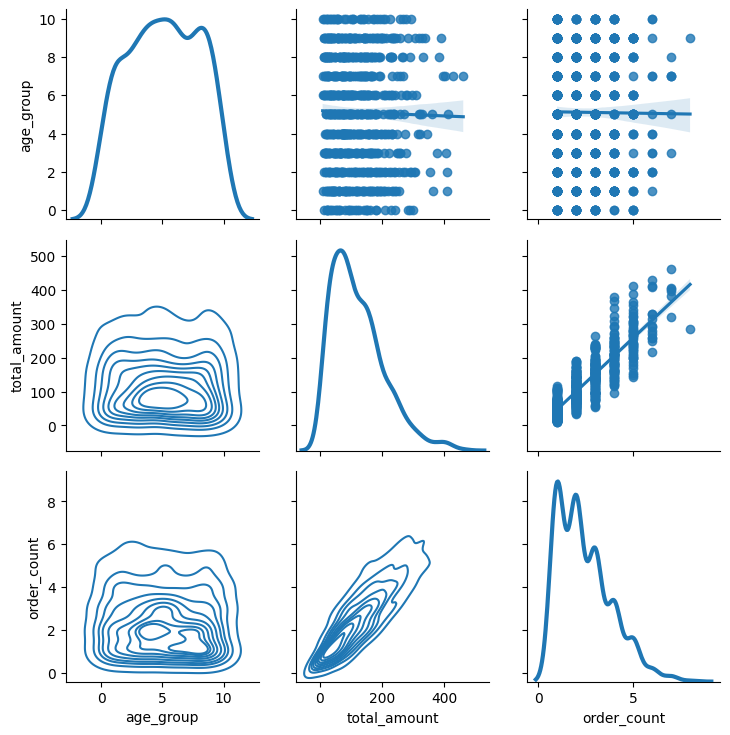

In [0]:
import seaborn as sns
g = sns.PairGrid(churn_dataset.sample(0.01).toPandas()[['age_group','total_amount','order_count']], diag_sharey=False)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3)
g.map_upper(sns.regplot)

### Further data analysis and preparation using pandas API

Because our Data Scientist team is familiar with Pandas, we'll use `pandas on spark` to scale `pandas` code. The Pandas instructions will be converted in the spark engine under the hood and distributed at scale.

Typicaly Data Science project would involve more advanced preparation and likely require extra data prep step, including more complex feature preparation. We'll keep it simple for this demo.

*Note: Starting from `spark 3.2`, koalas is builtin and we can get an Pandas Dataframe using `pandas_api()`.*

In [0]:
# Convert to koalas
dataset = churn_dataset.pandas_api()
dataset.describe()  
# Drop columns we don't want to use in our model
dataset = dataset.drop(columns=['address', 'email', 'firstname', 'lastname', 'creation_date', 'last_activity_date', 'last_event'])
# Drop missing values
dataset = dataset.dropna()   


## Write to Feature Store (Optional)

<img src="https://github.com/QuentinAmbard/databricks-demo/raw/main/product_demos/mlops-end2end-flow-feature-store.png" style="float:right" width="500" />

Once our features are ready, we'll save them in Databricks Feature Store. Under the hood, features store are backed by a Delta Lake table.

This will allow discoverability and reusability of our feature accross our organization, increasing team efficiency.

Feature store will bring traceability and governance in our deployment, knowing which model is dependent of which set of features. It also simplify realtime serving.

Make sure you're using the "Machine Learning" menu to have access to your feature store using the UI.

In [0]:
from databricks.feature_store import FeatureStoreClient

fs = FeatureStoreClient()

try:
  #drop table if exists
  fs.drop_table(f'{catalog}.{db}.churn_user_features')
except:
  pass
#Note: You might need to delete the FS table using the UI
churn_feature_table = fs.create_table(
  name=f'{catalog}.{db}.churn_user_features',
  primary_keys='user_id',
  schema=dataset.spark.schema(),
  description='These features are derived from the churn_bronze_customers table in the lakehouse.  We created dummy variables for the categorical columns, cleaned up their names, and added a boolean flag for whether the customer churned or not.  No aggregations were performed.'
)

fs.write_table(df=dataset.to_spark(), name=f'{catalog}.{db}.churn_user_features', mode='overwrite')
features = fs.read_table(f'{catalog}.{db}.churn_user_features')
display(features)

2025/12/09 16:42:09 WARNING databricks.ml_features._compute_client._compute_client: Deleting a feature table can lead to unexpected failures in upstream producers and downstream consumers (models, endpoints, and scheduled jobs).
2025/12/09 16:42:12 INFO databricks.ml_features._compute_client._compute_client: Setting columns ['user_id'] of table 'main.dbdemos_retail_c360.churn_user_features' to NOT NULL.
2025/12/09 16:42:13 INFO databricks.ml_features._compute_client._compute_client: Setting Primary Keys constraint ['user_id'] on table 'main.dbdemos_retail_c360.churn_user_features'.
2025/12/09 16:42:14 INFO databricks.ml_features._compute_client._compute_client: Created feature table 'main.dbdemos_retail_c360.churn_user_features'.


user_id,canal,country,gender,age_group,churn,order_count,total_amount,total_item,last_transaction,platform,event_count,session_count,days_since_creation,days_since_last_activity,days_last_event
ccbd668a-50b1-485c-bb82-7b994fed0fd7,WEBAPP,FR,1,6,0,3,161,5,2023-06-07T20:26:46Z,ios,3,3,1521,915,920
509b3da6-c25a-4b9a-b375-5ade442b95c2,WEBAPP,SPAIN,1,5,0,2,103,5,2023-06-08T21:50:54Z,ios,2,1,1367,919,916
a46211c0-d5d5-4067-9993-f23555724281,WEBAPP,USA,1,1,1,2,63,3,2023-06-04T10:09:18Z,android,2,2,1437,915,915
dddede45-aa29-4a2a-abb0-e6b5259a72b2,WEBAPP,USA,0,2,1,3,202,8,2023-06-05T04:53:53Z,ios,3,3,1342,920,922
9691861e-23fd-4ce4-b56a-e4ed0070c483,MOBILE,USA,1,6,1,4,146,7,2023-06-09T13:48:07Z,ios,4,4,1491,917,917
868381d4-be16-4bdb-a5d4-3fc5954933ae,WEBAPP,FR,0,1,1,3,125,5,2023-06-05T17:52:29Z,other,3,3,1559,914,915
f3887f37-b523-400a-9bf7-584d39eee42a,WEBAPP,USA,1,6,0,2,87,5,2023-06-09T15:32:55Z,ios,2,2,1327,920,915
2f722ef9-a136-4300-9c53-5014897b93fb,MOBILE,SPAIN,1,1,1,1,56,2,2023-06-09T19:13:29Z,other,1,1,1356,915,915
c2d16387-be68-4608-acc5-e6c20f291a2d,WEBAPP,USA,1,1,1,5,249,9,2023-06-08T19:44:38Z,ios,5,5,1258,914,922
27cd9d49-c013-4ab4-8b23-aefe7e8806ce,PHONE,USA,1,7,0,7,408,13,2023-06-06T10:30:11Z,ios,7,7,1191,917,916



## Accelerating Churn model creation using MLFlow and Databricks Auto-ML

MLflow is an open source project allowing model tracking, packaging and deployment. Everytime your datascientist team work on a model, Databricks will track all the parameter and data used and will save it. This ensure ML traceability and reproductibility, making it easy to know which model was build using which parameters/data.

### A glass-box solution that empowers data teams without taking away control

While Databricks simplify model deployment and governance (MLOps) with MLFlow, bootstraping new ML projects can still be long and inefficient. 

Instead of creating the same boilerplate for each new project, Databricks Auto-ML can automatically generate state of the art models for Classifications, regression, and forecast.


<img width="1000" src="https://github.com/QuentinAmbard/databricks-demo/raw/main/retail/resources/images/auto-ml-full.png"/>


Models can be directly deployed, or instead leverage generated notebooks to boostrap projects with best-practices, saving you weeks of efforts.

<br style="clear: both">

<img style="float: right" width="600" src="https://github.com/QuentinAmbard/databricks-demo/raw/main/retail/resources/images/churn-auto-ml.png"/>

### Using Databricks Auto ML with our Churn dataset

Auto ML is available in the "Machine Learning" space. All we have to do is start a new Auto-ML experimentation and select the feature table we just created (`churn_features`)

Our prediction target is the `churn` column.

Click on Start, and Databricks will do the rest.

While this is done using the UI, you can also leverage the [python API](https://docs.databricks.com/applications/machine-learning/automl.html#automl-python-api-1)

<br style="clear: both">
<div style="background-color:#bde6ff; border-radius:15px; padding: 15px; margin: 15px">Note: Databricks AutoML classification through serverless API is coming soon on dbdemos! If you're using an express workspace, you can skip this step as we provided you with the notebook!</div>

In [0]:
xp_path = "/Shared/dbdemos/experiments/lakehouse-retail-c360"
xp_name = f"automl_churn_{datetime.now().strftime('%Y-%m-%d_%H:%M:%S')}"
try:
    from databricks import automl
    automl_run = automl.classify(
        experiment_name = xp_name,
        experiment_dir = xp_path,
        dataset = fs.read_table(f'{catalog}.{db}.churn_user_features'),
        target_col = "churn",
        timeout_minutes = 10
    )
    #Make sure all users can access dbdemos shared experiment
    DBDemos.set_experiment_permission(f"{xp_path}/{xp_name}")
except Exception as e:
    if "cannot import name 'automl'" in str(e) or 'method_whitelist' in str(e):
        # Note: cannot import name 'automl' from 'databricks' likely means you're using serverless. Dbdemos doesn't support autoML serverless API - this will be improved soon.
        # Adding a temporary workaround to make sure it works well for now - ignore this for classic run
        DBDemos.create_mockup_automl_run(f"{xp_path}/{xp_name}", fs.read_table(f'{catalog}.{db}.churn_user_features').toPandas())
    else:
        raise e

(2025-12-09 16:42:20) WARNING: Hyperopt is deprecated for Databricks runtime for machine learning and will not be pre-installed in the next major version.
2025/12/09 16:42:23 INFO databricks.automl.client.manager: AutoML will optimize for F1 score metric, which is tracked as val_f1_score in the MLflow experiment.
2025/12/09 16:42:24 INFO databricks.automl.shared.databricks_utils: No host name to create absolute URL
2025/12/09 16:42:24 INFO databricks.automl.client.manager: MLflow Experiment ID: 4488749743267145
2025/12/09 16:42:24 INFO databricks.automl.client.manager: MLflow Experiment: #mlflow/experiments/4488749743267145
2025/12/09 16:43:46 INFO databricks.automl.shared.databricks_utils: No host name to create absolute URL
2025/12/09 16:43:46 INFO databricks.automl.client.manager: Data exploration notebook: #notebook/4488749743267150
2025/12/09 16:53:03 INFO databricks.automl.client.manager: AutoML experiment completed successfully.


,Train,Validation,Test
f1_score,0.862,0.858,0.863
recall_score,0.872,0.868,0.875
roc_auc,0.890,0.789,0.795
false_negatives,3350.000,1169.000,1102.000
false_positives,3987.000,1375.000,1327.000
example_count,40048.000,13501.000,13394.000
precision_score,0.852,0.848,0.853
true_positives,22924.000,7692.000,7679.000
precision_recall_auc,0.934,0.837,0.837
true_negatives,9787.000,3265.000,3286.000


Experiment on /Shared/dbdemos/experiments/lakehouse-retail-c360/automl_churn_2025-12-09_16:42:19 was set public


AutoML saved our best model in the MLFlow registry. Open the experiment from the AutoML run to explore its artifact and analyze the parameters used, including traceability to the notebook used for its creation.

If we're ready, we can move this model into Production stage in a click, or using the API.

### The model generated by AutoML is ready to be used in our SDP pipeline to detect customers about to churn.

Our Data Engineer can now easily retrive the model `dbdemos_customer_churn` from our Auto ML run and predict churn within our Spark Declarative Pipelines Pipeline.<br>
Re-open the SDP pipeline to see how this is done.

#### Track churn impact over the next month and campaign impact

This churn prediction can be re-used in our dashboard to analyse future churn, take actiond and measure churn reduction. 

The pipeline created with the Lakehouse will offer a strong ROI: it took us a few hours to setup this pipeline end 2 end and we have potential gain for $129,914 / month!

<img width="800px" src="https://raw.githubusercontent.com/QuentinAmbard/databricks-demo/main/retail/resources/images/lakehouse-retail/lakehouse-retail-churn-dbsql-prediction-dashboard.png">

<a href='/sql/dashboards/f25702b4-56d8-40a2-a69d-d2f0531a996f'>Open the Churn prediction DBSQL dashboard</a> | [Go back to the introduction]($../00-churn-introduction-lakehouse)

#### More advanced model deployment (batch or serverless realtime)

We can also use the model `dbdemos_custom_churn` and run our predict in a standalone batch or realtime inferences! 

Next step:  [Explore the generated Auto-ML notebook]($./04.2-automl-generated-notebook) and [Run inferences in production]($./04.3-running-inference)